# 🩺 Project 80 of 100 — Dr. Semmelweis and the Handwashing Revolution

Welcome to Project 80 of 100.

Today, let's step into the shoes of Dr. Ignaz Semmelweis — not just as analysts, but as scientific detectives. 

In a time when people blamed illness on “bad air” or spirits (imagínate eso), Semmelweis dared to follow the data.

The mission:
To investigate why so many women were dying from childbed fever in Vienna General Hospital during the 1840s — and to determine whether handwashing changed everything.

Let’s get to work!

---

## 1️⃣ Environment Setup

In [1]:
# Core Data Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px

# Statistics
import scipy.stats as stats

# Improve display format
pd.options.display.float_format = '{:,.2f}'.format

# Date formatting helpers
years = mdates.YearLocator()
months = mdates.MonthLocator()
years_fmt = mdates.DateFormatter('%Y')

from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

print("Environment ready. Vamos pues.")

Environment ready. Vamos pues.


## 2️⃣ Load the Data

There are two datasets:

- `annual_deaths_by_clinic.csv`
- `monthly_deaths.csv`

These datasets contain birth and death records collected between 1841 and 1849.

In [2]:
df_yearly = pd.read_csv("annual_deaths_by_clinic.csv")
df_monthly = pd.read_csv("monthly_deaths.csv", parse_dates=["date"])

df_yearly.head()

,year,births,deaths,clinic
0,1841,3036,237,clinic 1
1,1842,3287,518,clinic 1
2,1843,3060,274,clinic 1
3,1844,3157,260,clinic 1
4,1845,3492,241,clinic 1


## 3️⃣ Preliminary Exploration

Before making bold medical conclusions, let's understand the data structure.
No assumptions. Only evidence.

In [3]:
print("Yearly shape:", df_yearly.shape)
print("Any missing values (Yearly)?", df_yearly.isna().values.any())
print("Any duplicates (Yearly)?", df_yearly.duplicated().values.any())
df_yearly.info()

Yearly shape: (12, 4)
Any missing values (Yearly)? False
Any duplicates (Yearly)? False
<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   year    12 non-null     int64
 1   births  12 non-null     int64
 2   deaths  12 non-null     int64
 3   clinic  12 non-null     str  
dtypes: int64(3), str(1)
memory usage: 516.0 bytes


In [4]:
print("Monthly shape:", df_monthly.shape)
print("Any missing values (Monthly)?", df_monthly.isna().values.any())
print("Any duplicates (Monthly)?", df_monthly.duplicated().values.any())
df_monthly.info()

Monthly shape: (98, 3)
Any missing values (Monthly)? False
Any duplicates (Monthly)? False
<class 'pandas.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    98 non-null     datetime64[us]
 1   births  98 non-null     int64         
 2   deaths  98 non-null     int64         
dtypes: datetime64[us](1), int64(2)
memory usage: 2.4 KB


## 4️⃣ How Dangerous Was Childbirth?

Let’s calculate the overall maternal mortality rate during the 1840s.

For context:
In 2013, the U.S. maternal mortality rate was 0.018%.

Now let’s see Vienna in the 1840s...

In [5]:
mortality_rate = df_yearly.deaths.sum() / df_yearly.births.sum() * 100
print(f"Maternal mortality rate in 1840s Vienna: {mortality_rate:.3f}%")

Maternal mortality rate in 1840s Vienna: 7.084%


## 5️⃣ Monthly Births vs Deaths (Twin Axes)

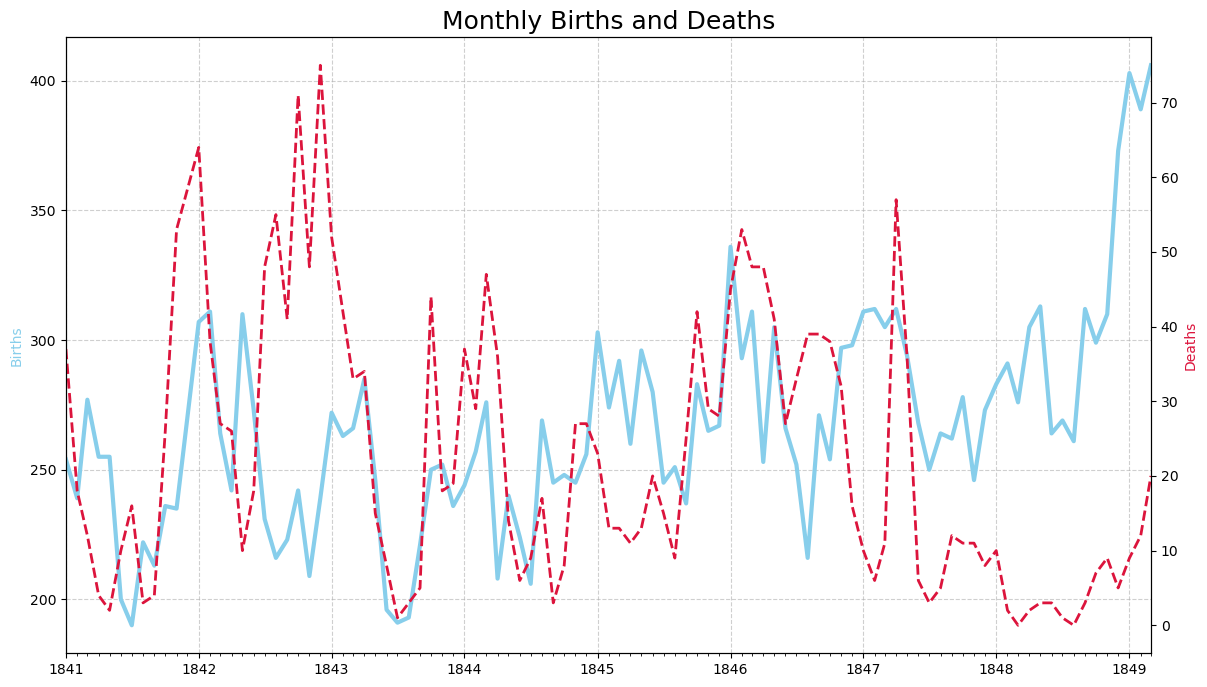

In [6]:
plt.figure(figsize=(14,8))
plt.title("Monthly Births and Deaths", fontsize=18)

ax1 = plt.gca()
ax2 = ax1.twinx()

ax1.plot(df_monthly.date, df_monthly.births,
         color="skyblue", linewidth=3)

ax2.plot(df_monthly.date, df_monthly.deaths,
         color="crimson", linewidth=2, linestyle="--")

ax1.set_ylabel("Births", color="skyblue")
ax2.set_ylabel("Deaths", color="crimson")

ax1.set_xlim(df_monthly.date.min(), df_monthly.date.max())
ax1.xaxis.set_major_locator(years)
ax1.xaxis.set_major_formatter(years_fmt)
ax1.xaxis.set_minor_locator(months)

ax1.grid(True, linestyle="--", alpha=0.6)

plt.show()

## 6️⃣ The Handwashing Policy

In June 1847, Dr. Semmelweis introduced mandatory handwashing using chlorinated lime.

Let’s measure its impact.

In [7]:
handwashing_start = pd.to_datetime("1847-06-01")

df_monthly["pct_deaths"] = df_monthly.deaths / df_monthly.births

before = df_monthly[df_monthly.date < handwashing_start]
after = df_monthly[df_monthly.date >= handwashing_start]

before_rate = before.pct_deaths.mean() * 100
after_rate = after.pct_deaths.mean() * 100

print(f"Before handwashing: {before_rate:.3f}%")
print(f"After handwashing: {after_rate:.3f}%")

Before handwashing: 10.505%
After handwashing: 2.109%


## 7️⃣ Statistical Significance (T-Test)

We now test:

H0: There is no difference in death rates  
H1: There is a difference  

If p-value < 0.01 → statistically significant at 99% confidence.

In [8]:
t_stat, p_value = stats.ttest_ind(before.pct_deaths, after.pct_deaths)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.10f}")

T-statistic: 5.5116
P-value: 0.0000002985


## 🧾 Final Diagnosis

The data clearly shows a dramatic reduction in maternal mortality after mandatory handwashing.

The t-test confirms the difference is statistically significant.

Conclusion:

Handwashing saved lives.

Semmelweis was right.

Sometimes science advances not with big speeches — but with soap and water.